# Kombinalt Dataset
- a cross-dataset kiserlet utan, ugy gondoltam erdemes lenne a ket datasetet osszevonni, es az igy kapott kombinalt datasetel tanitani ugyan azt a halot
- ez a dataset bovitheto mas datasetekkel is, es gyarapodhat tobb fele keppel, ezzel robosztusabba teve a halot

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
 
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
 
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
 
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
 
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Konfiguracio

In [3]:
DATASET_DIR = "/kaggle/input/datasets/balazsakos/combined-chest-xray-dataset/combined_dataset"
TRAIN_DIR   = os.path.join(DATASET_DIR, "train")
VAL_DIR     = os.path.join(DATASET_DIR, "val")
TEST_DIR    = os.path.join(DATASET_DIR, "test")
 
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 32
EPOCHS_INITIAL = 20
EPOCHS_FINE    = 40
SEED           = 42
 
OUT_ROOT  = "/kaggle/working"
FIG_DIR   = os.path.join(OUT_ROOT, "figures")
MET_DIR   = os.path.join(OUT_ROOT, "metrics")
MODEL_DIR = os.path.join(OUT_ROOT, "models")
 
os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(MET_DIR,   exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

### Preprocess: Crop + CLAHE

In [4]:
CROP_TOP    = 0.15
CROP_BOTTOM = 0.90
CROP_LEFT   = 0.05
CROP_RIGHT  = 0.95
 
def crop_clahe(img):
    img_uint8 = np.clip(img, 0, 255).astype('uint8')
    h, w = img_uint8.shape[:2]
    y1, y2 = int(h * CROP_TOP),   int(h * CROP_BOTTOM)
    x1, x2 = int(w * CROP_LEFT),  int(w * CROP_RIGHT)
    cropped = cv2.resize(img_uint8[y1:y2, x1:x2], (224, 224))
    lab = cv2.cvtColor(cropped, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    cl = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
    final_img = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB)
    return preprocess_input(final_img.astype('float32'))

### Adatgeneratorok

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=crop_clahe,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False
)
 
val_test_datagen = ImageDataGenerator(
    preprocessing_function=crop_clahe
)
 
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=SEED
)
 
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
 
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
 
print("Class indices:", train_gen.class_indices)

Found 8988 images belonging to 2 classes.
Found 1124 images belonging to 2 classes.
Found 1124 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


### Class weight

In [6]:
counts = np.bincount(train_gen.classes)
total  = counts.sum()
class_weight = {0: total / (2 * counts[0]), 1: total / (2 * counts[1])}
print("Train class counts:", counts, "| class_weight:", class_weight)

Train class counts: [4494 4494] | class_weight: {0: np.float64(1.0), 1: np.float64(1.0)}


### Preprocess Sanity Check

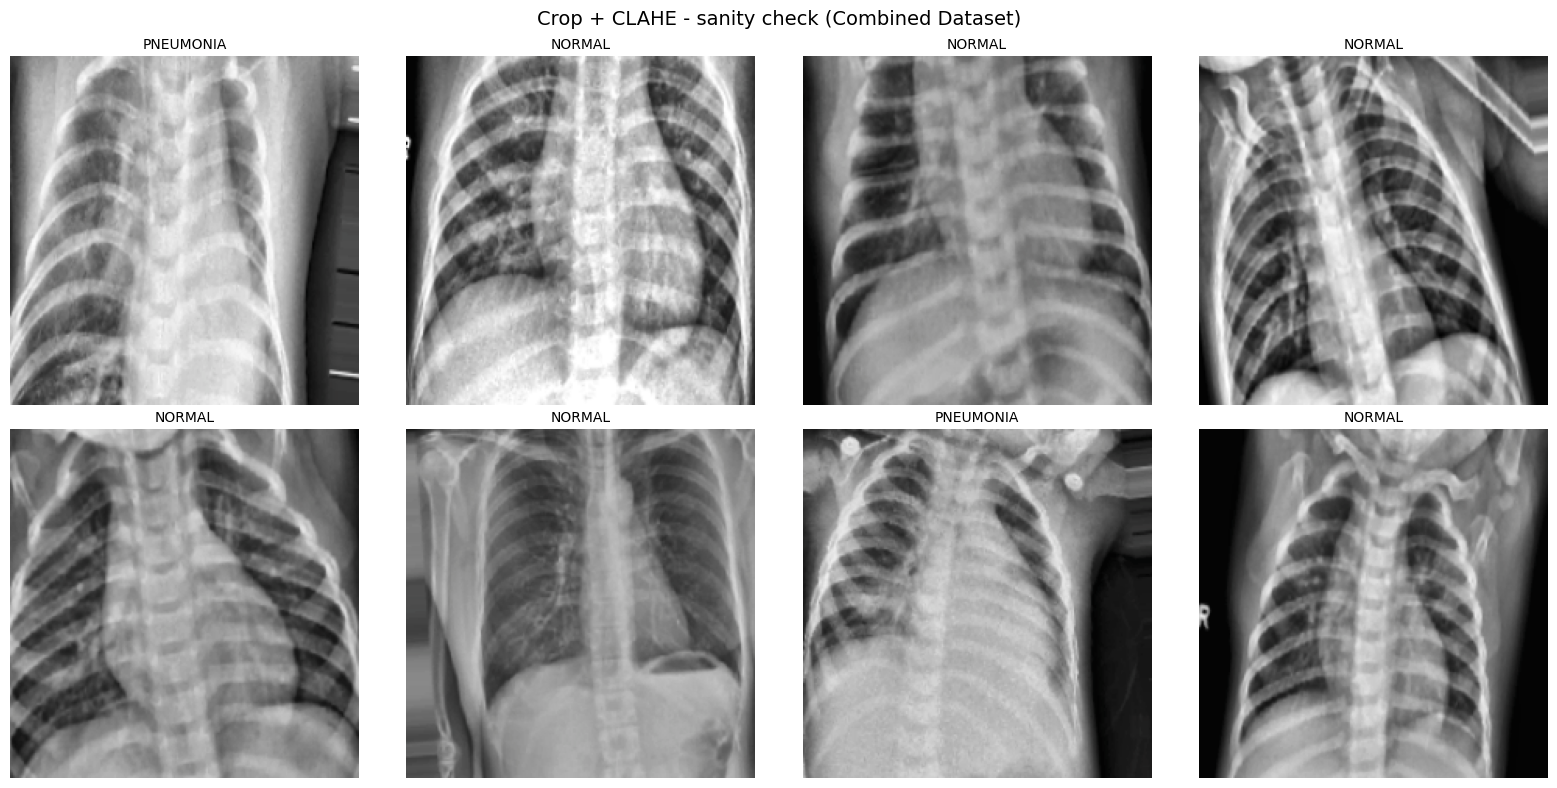

Saved: /kaggle/working/figures/preprocessing_sanity_check.png


In [7]:
def visualize_preprocessing(gen, n=8, title="Preprocessing sanity check"):
    gen.reset()
    batch_imgs, batch_labels = next(gen)
    idx_to_class = {v: k for k, v in gen.class_indices.items()}
 
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
    plt.suptitle(title, fontsize=14)
 
    for i in range(min(n, len(batch_imgs))):
        img = batch_imgs[i].copy()
        img[..., 0] += 103.939
        img[..., 1] += 116.779
        img[..., 2] += 123.68
        img = img[..., ::-1]
        img = np.clip(img, 0, 255).astype('uint8')
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(idx_to_class[int(batch_labels[i])], fontsize=10)
        plt.axis("off")
 
    plt.tight_layout()
    sanity_path = os.path.join(FIG_DIR, "preprocessing_sanity_check.png")
    plt.savefig(sanity_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", sanity_path)
    gen.reset()
 
visualize_preprocessing(train_gen, n=8, title="Crop + CLAHE - sanity check (Combined Dataset)")

### Modell-VGG16

In [8]:
base = VGG16(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(224, 224, 3))
)
 
for layer in base.layers:
    layer.trainable = False
 
x = GlobalAveragePooling2D()(base.output)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
out = Dense(1, activation='sigmoid')(x)
 
model = Model(inputs=base.inputs, outputs=out)
 
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
 
model.summary()

I0000 00:00:1778682983.270574      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           51

 Total params: 14,979,905 (57.14 MB)

 Trainable params: 264,193 (1.01 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

### Callbackek

In [9]:
ckpt_path = os.path.join(MODEL_DIR, "vgg16_combined_best.keras")
 
callbacks1 = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True)
]

callbacks2 = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True)
]

### Phase1-Training

In [10]:
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_INITIAL,
    callbacks=callbacks1,
    class_weight=class_weight
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1778683085.778835     172 service.cc:152] XLA service 0x78c0bc00d8e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778683085.778878     172 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778683086.405810     172 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/281 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.4219 - loss: 1.0543 

I0000 00:00:1778683095.020670     172 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


281/281 ━━━━━━━━━━━━━━━━━━━━ 226s 765ms/step - accuracy: 0.7909 - loss: 0.4273 - val_accuracy: 0.9528 - val_loss: 0.1483 - learning_rate: 1.0000e-04
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 176s 625ms/step - accuracy: 0.9273 - loss: 0.1754 - val_accuracy: 0.9626 - val_loss: 0.1071 - learning_rate: 1.0000e-04
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 172s 610ms/step - accuracy: 0.9493 - loss: 0.1348 - val_accuracy: 0.9653 - val_loss: 0.0954 - learning_rate: 1.0000e-04
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 170s 603ms/step - accuracy: 0.9559 - loss: 0.1196 - val_accuracy: 0.9653 - val_loss: 0.0889 - learning_rate: 1.0000e-04
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 170s 606ms/step - accuracy: 0.9528 - loss: 0.1171 - val_accuracy: 0.9671 - val_loss: 0.0834 - learning_rate: 1.0000e-04
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 170s 605ms/step - accuracy: 0.9580 - loss: 0.1074 - val_accuracy: 0.9680 - val_loss: 0.0830 - learning_rate: 1.0000e-04
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 171s 607ms/

### Phase2-Fine Tuning

In [12]:
for layer in base.layers:
    layer.trainable = "block5" in layer.name
 
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=callbacks2,
    class_weight=class_weight
)

Epoch 1/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 185s 642ms/step - accuracy: 0.9725 - loss: 0.0769 - val_accuracy: 0.9804 - val_loss: 0.0519 - learning_rate: 1.0000e-05
Epoch 2/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 177s 631ms/step - accuracy: 0.9765 - loss: 0.0657 - val_accuracy: 0.9822 - val_loss: 0.0481 - learning_rate: 1.0000e-05
Epoch 3/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 171s 610ms/step - accuracy: 0.9808 - loss: 0.0520 - val_accuracy: 0.9840 - val_loss: 0.0465 - learning_rate: 1.0000e-05
Epoch 4/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 174s 620ms/step - accuracy: 0.9834 - loss: 0.0455 - val_accuracy: 0.9831 - val_loss: 0.0476 - learning_rate: 1.0000e-05
Epoch 5/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 174s 617ms/step - accuracy: 0.9847 - loss: 0.0419 - val_accuracy: 0.9875 - val_loss: 0.0473 - learning_rate: 1.0000e-05
Epoch 6/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 176s 627ms/step - accuracy: 0.9869 - loss: 0.0418 - val_accuracy: 0.9893 - val_loss: 0.0388 - learning_rate: 1.0000e-05
Epoch 7/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 

### Grafikonok

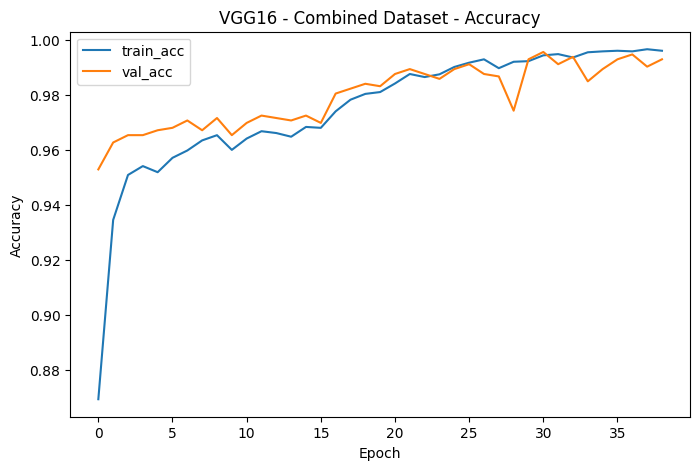

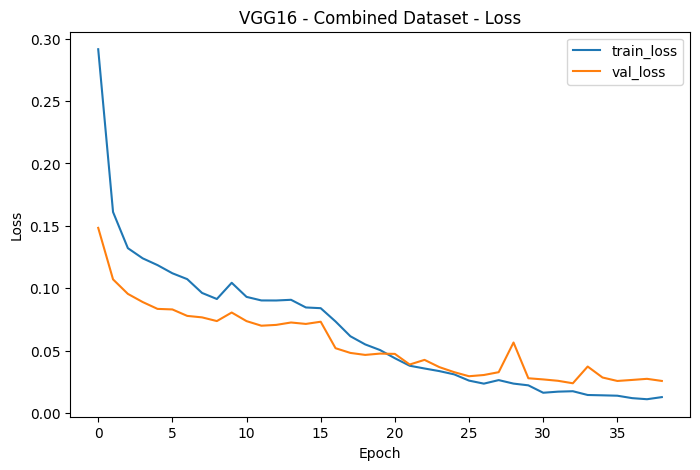

Saved: /kaggle/working/figures/vgg16_combined_accuracy.png
Saved: /kaggle/working/figures/vgg16_combined_loss.png


In [13]:
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history.keys():
        merged[k] = h1.history[k] + h2.history[k]
    return merged
 
hist = merge_histories(history1, history2)
 
plt.figure(figsize=(8, 5))
plt.plot(hist["accuracy"],     label="train_acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 - Combined Dataset - Accuracy")
plt.legend()
acc_path = os.path.join(FIG_DIR, "vgg16_combined_accuracy.png")
plt.savefig(acc_path, dpi=150, bbox_inches="tight")
plt.show()
 
plt.figure(figsize=(8, 5))
plt.plot(hist["loss"],     label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 - Combined Dataset - Loss")
plt.legend()
loss_path = os.path.join(FIG_DIR, "vgg16_combined_loss.png")
plt.savefig(loss_path, dpi=150, bbox_inches="tight")
plt.show()
 
print("Saved:", acc_path)
print("Saved:", loss_path)

### Kiertekeles + JSON mentes

Threshold | Accuracy | Sensitivity | Specificity
0.30       | 0.9902   | 0.9964     | 0.9840
0.35       | 0.9911   | 0.9964     | 0.9858
0.40       | 0.9911   | 0.9964     | 0.9858
0.45       | 0.9911   | 0.9947     | 0.9875
0.50       | 0.9911   | 0.9947     | 0.9875
0.55       | 0.9911   | 0.9929     | 0.9893
0.60       | 0.9884   | 0.9875     | 0.9893
0.65       | 0.9884   | 0.9875     | 0.9893
0.70       | 0.9884   | 0.9875     | 0.9893
0.75       | 0.9893   | 0.9875     | 0.9911
0.80       | 0.9893   | 0.9875     | 0.9911


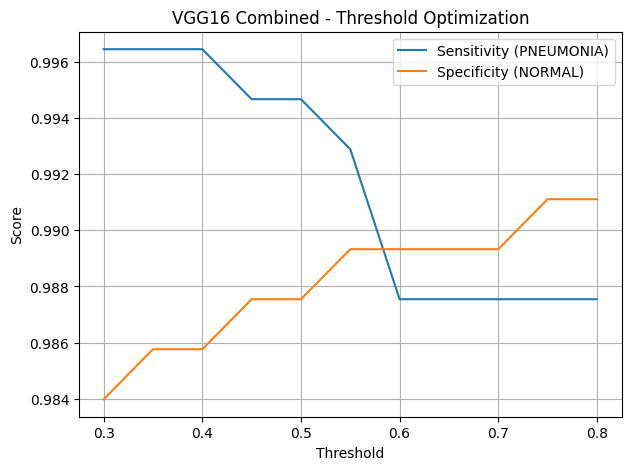

              precision    recall  f1-score   support

      NORMAL       0.99      0.99      0.99       562
   PNEUMONIA       0.99      0.99      0.99       562

    accuracy                           0.99      1124
   macro avg       0.99      0.99      0.99      1124
weighted avg       0.99      0.99      0.99      1124



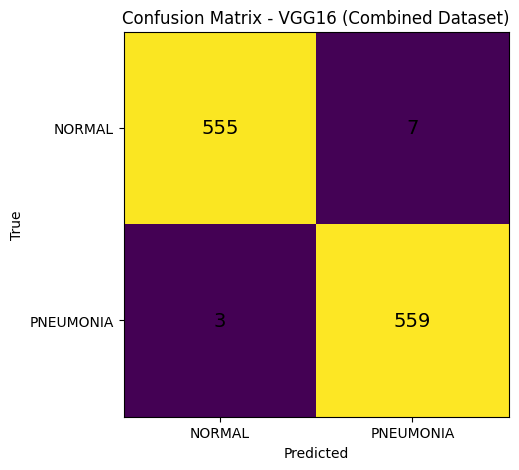

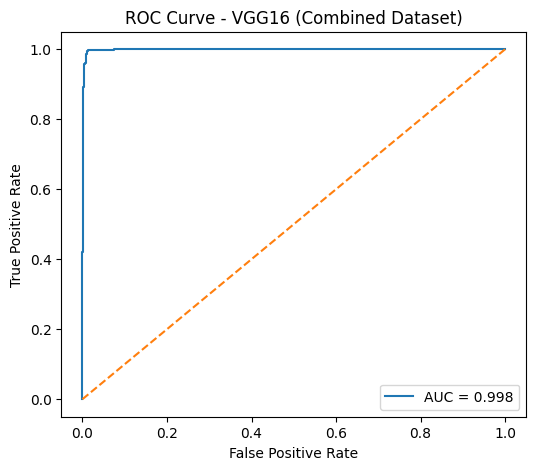

Saved: /kaggle/working/figures/vgg16_combined_confusion_matrix.png
Saved: /kaggle/working/figures/vgg16_combined_roc.png
Saved: /kaggle/working/metrics/vgg16_combined_dataset_metrics.json


In [14]:
model.load_weights(ckpt_path)
 
test_gen.reset()
y_prob = model.predict(test_gen, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes
 
thresholds = np.arange(0.3, 0.81, 0.05)
results = []
 
for th in thresholds:
    y_pred_th = (y_prob >= th).astype(int)
    cm_th = confusion_matrix(y_true, y_pred_th)
    tn, fp, fn, tp = cm_th.ravel()
    results.append((
        th,
        accuracy_score(y_true, y_pred_th),
        tp / (tp + fn),
        tn / (tn + fp)
    ))
 
print("Threshold | Accuracy | Sensitivity | Specificity")
for r in results:
    print(f"{r[0]:.2f}       | {r[1]:.4f}   | {r[2]:.4f}     | {r[3]:.4f}")
 
plt.figure(figsize=(7, 5))
plt.plot([r[0] for r in results], [r[2] for r in results], label="Sensitivity (PNEUMONIA)")
plt.plot([r[0] for r in results], [r[3] for r in results], label="Specificity (NORMAL)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("VGG16 Combined - Threshold Optimization")
plt.legend()
plt.grid(True)
plt.show()
 
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))
 
report = classification_report(
    y_true, y_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    output_dict=True
)
 
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5.5, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - VGG16 (Combined Dataset)")
plt.xticks([0, 1], ["NORMAL", "PNEUMONIA"])
plt.yticks([0, 1], ["NORMAL", "PNEUMONIA"])
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("True")
cm_path = os.path.join(FIG_DIR, "vgg16_combined_confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
 
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - VGG16 (Combined Dataset)")
plt.legend()
roc_path = os.path.join(FIG_DIR, "vgg16_combined_roc.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
 
metrics_out = {
    "model": "VGG16_transfer_Combined_Dataset",
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_total": len(hist["loss"]),
    "roc_auc": float(roc_auc),
    "confusion_matrix": cm.tolist(),
    "classification_report": report
}
 
met_path = os.path.join(MET_DIR, "vgg16_combined_dataset_metrics.json")
with open(met_path, "w") as f:
    json.dump(metrics_out, f, indent=2)
 
print("Saved:", cm_path)
print("Saved:", roc_path)
print("Saved:", met_path)

### Modell save

In [15]:
final_model_path = os.path.join(MODEL_DIR, "vgg16_combined_final.keras")
model.save(final_model_path)
print("Saved:", final_model_path)

Saved: /kaggle/working/models/vgg16_combined_final.keras


### Random predikciok

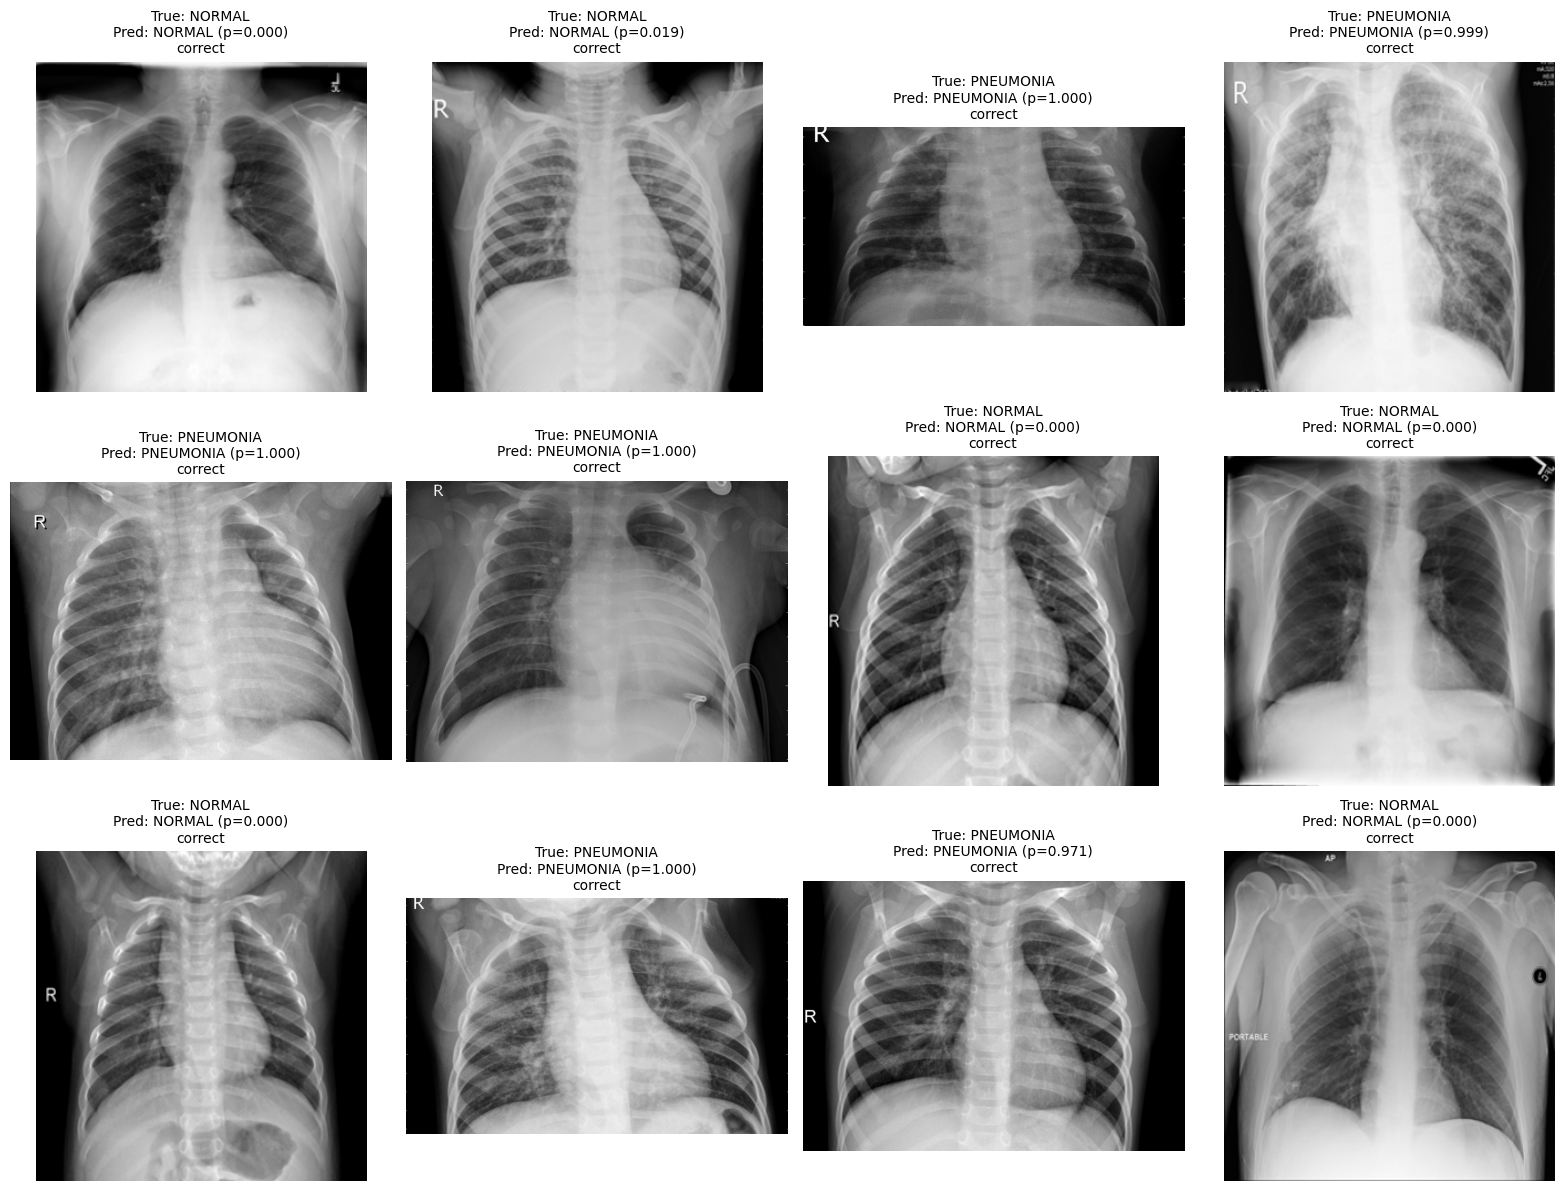

In [16]:
def show_predictions_grid(model, test_gen, n=12, threshold=0.5, seed=42):
    rng = np.random.default_rng(seed)
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_true = test_gen.classes
    y_pred = (y_prob >= threshold).astype(int)
    idxs = rng.choice(len(y_true), size=min(n, len(y_true)), replace=False)
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    class_names  = [idx_to_class[0], idx_to_class[1]]
 
    cols = 4
    rows = int(np.ceil(len(idxs) / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
 
    for i, idx in enumerate(idxs, start=1):
        img        = plt.imread(test_gen.filepaths[idx])
        true_label = y_true[idx]
        pred_label = y_pred[idx]
        prob       = y_prob[idx]
        correct    = (true_label == pred_label)
        title = (
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]} (p={prob:.3f})\n"
            f"{'correct' if correct else 'wrong'}"
        )
        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap="gray" if img.ndim == 2 else None)
        plt.axis("off")
        plt.title(title, fontsize=10)
 
    plt.tight_layout()
    plt.show()
 
show_predictions_grid(model, test_gen, n=12, threshold=0.5, seed=42)

### Top hibak

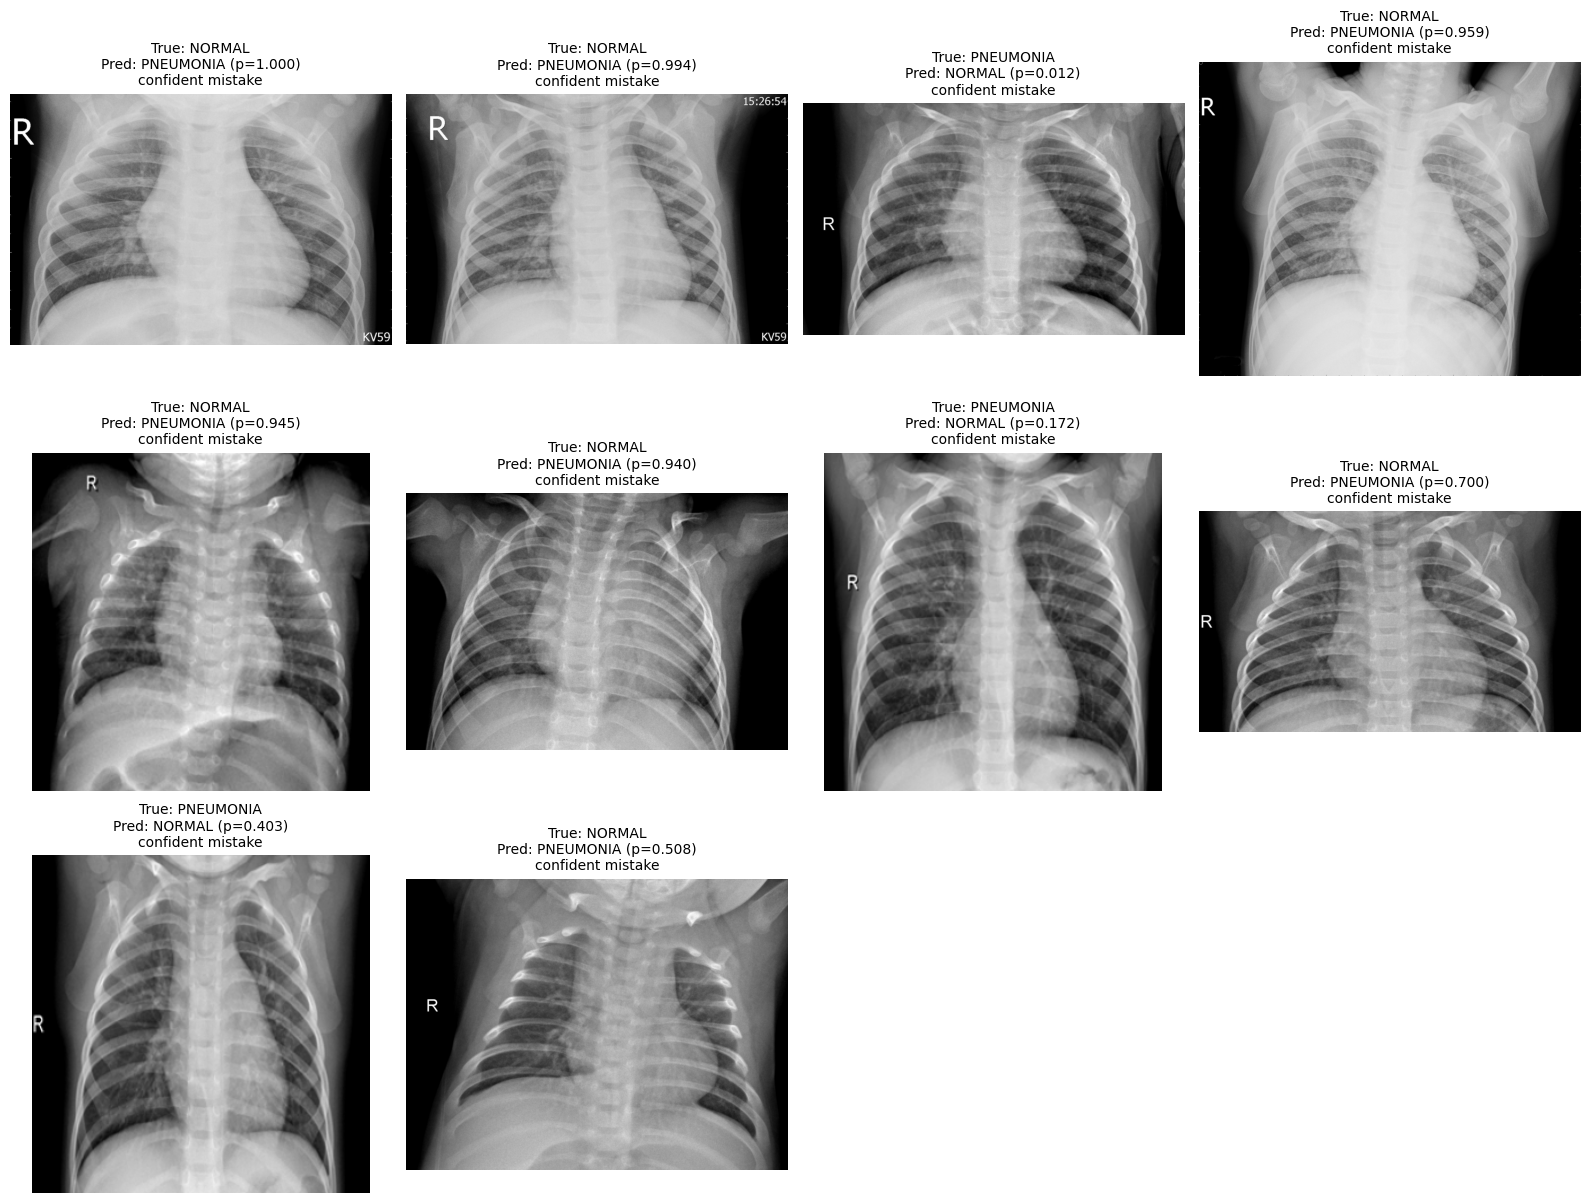

In [17]:
def show_top_mistakes(model, test_gen, k=12, threshold=0.5):
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_true = test_gen.classes
    y_pred = (y_prob >= threshold).astype(int)
 
    wrong = np.where(y_true != y_pred)[0]
    if len(wrong) == 0:
        print("No mistakes on the test set with this threshold.")
        return
 
    confidence   = np.abs(y_prob[wrong] - threshold)
    top_wrong    = wrong[np.argsort(-confidence)][:min(k, len(wrong))]
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    class_names  = [idx_to_class[0], idx_to_class[1]]
 
    cols = 4
    rows = int(np.ceil(len(top_wrong) / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
 
    for i, idx in enumerate(top_wrong, start=1):
        img        = plt.imread(test_gen.filepaths[idx])
        true_label = y_true[idx]
        pred_label = y_pred[idx]
        prob       = y_prob[idx]
        title = (
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]} (p={prob:.3f})\n"
            f"confident mistake"
        )
        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap="gray" if img.ndim == 2 else None)
        plt.axis("off")
        plt.title(title, fontsize=10)
 
    plt.tight_layout()
    plt.show()
 
show_top_mistakes(model, test_gen, k=12, threshold=0.5)

### Grad-CAM

Last conv layer: block5_conv3


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


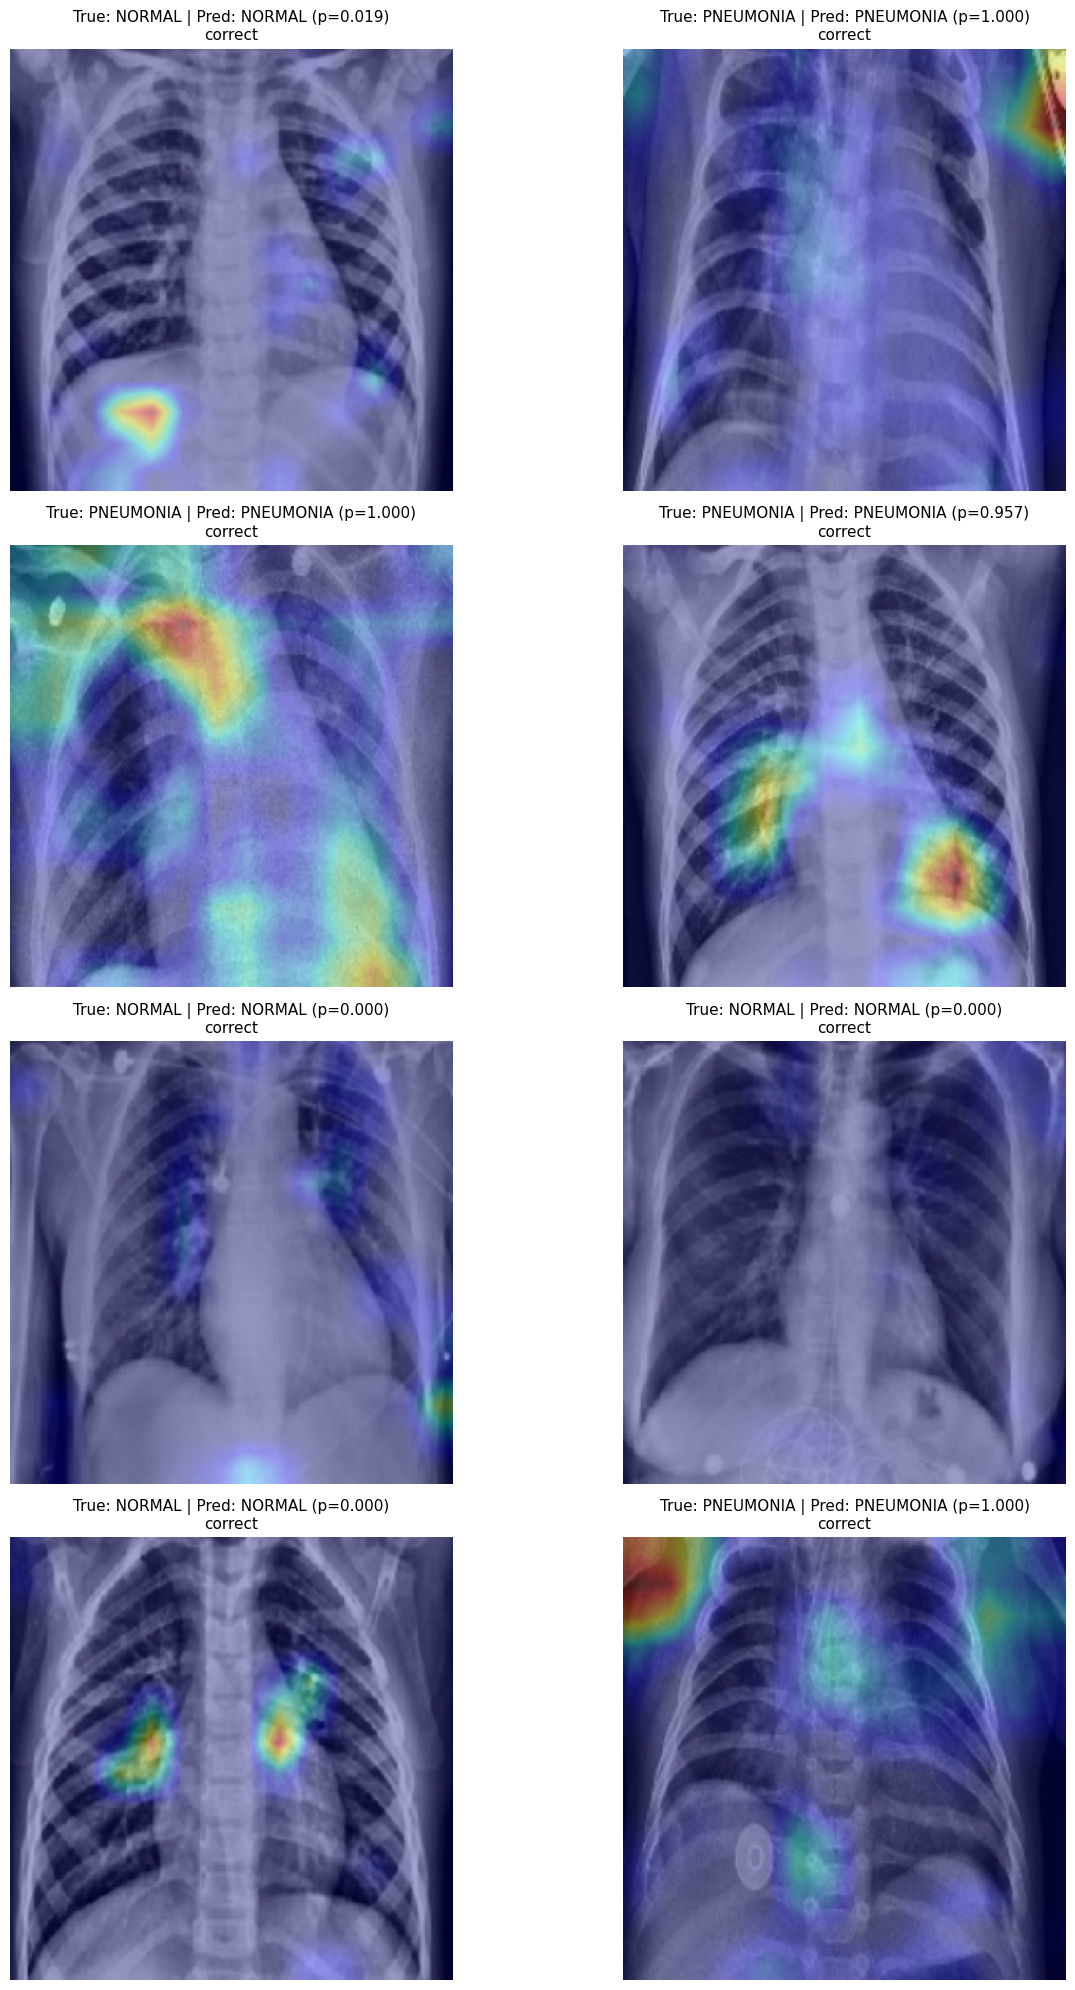

Saved Grad-CAM overlays to: /kaggle/working/figures/gradcam_vgg16_combined


In [18]:
def find_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found")
 
last_conv_name = find_last_conv_layer_name(model)
print("Last conv layer:", last_conv_name)
 
def make_gradcam_heatmap(img_batch, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_batch, training=False)
        score = preds[:, 0]
    grads        = tape.gradient(score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))
    conv_out     = conv_out[0]
    pooled_grads = pooled_grads[0]
    heatmap      = tf.reduce_sum(conv_out * pooled_grads, axis=-1)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap     /= (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()
 
def overlay_heatmap(img_rgb_01, heatmap, alpha=0.35):
    heatmap_tf      = tf.convert_to_tensor(heatmap[..., np.newaxis], dtype=tf.float32)
    heatmap_tf      = tf.image.resize(heatmap_tf, (img_rgb_01.shape[0], img_rgb_01.shape[1]))
    heatmap_resized = heatmap_tf.numpy().squeeze()
    colored         = plt.get_cmap("jet")(heatmap_resized)[:, :, :3]
    return np.clip((1 - alpha) * img_rgb_01 + alpha * colored, 0, 1)
 
def deprocess_vgg16_image(x):
    x = x.copy()
    x[..., 0] += 103.939
    x[..., 1] += 116.779
    x[..., 2] += 123.68
    x = x[..., ::-1]
    return np.clip(x, 0, 255) / 255.0
 
def gradcam_on_test_samples(model, test_gen, last_conv_layer_name,
                             n=8, threshold=0.5, seed=42,
                             save_dir="/kaggle/working/figures/gradcam_vgg16_combined"):
    rng = np.random.default_rng(seed)
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_true = test_gen.classes
    y_pred = (y_prob >= threshold).astype(int)
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    class_names  = [idx_to_class[0], idx_to_class[1]]
    idxs = rng.choice(len(y_true), size=min(n, len(y_true)), replace=False)
    os.makedirs(save_dir, exist_ok=True)
 
    cols = 2
    rows = int(np.ceil(len(idxs) / cols))
    plt.figure(figsize=(cols * 7, rows * 5))
 
    for i, idx in enumerate(idxs, start=1):
        filepath      = test_gen.filepaths[idx]
        pil_img       = tf.keras.utils.load_img(filepath, target_size=test_gen.target_size)
        img_arr       = tf.keras.utils.img_to_array(pil_img)
        img_for_model = crop_clahe(img_arr.copy())
        img_rgb_01    = deprocess_vgg16_image(img_for_model)
        img_batch     = np.expand_dims(img_for_model, axis=0)
 
        heatmap     = make_gradcam_heatmap(img_batch, model, last_conv_layer_name)
        overlay_img = overlay_heatmap(img_rgb_01, heatmap, alpha=0.35)
 
        true_label = y_true[idx]
        pred_label = y_pred[idx]
        prob       = y_prob[idx]
        correct    = (true_label == pred_label)
 
        title = (
            f"True: {class_names[true_label]} | Pred: {class_names[pred_label]} (p={prob:.3f})\n"
            f"{'correct' if correct else 'wrong'}"
        )
        plt.subplot(rows, cols, i)
        plt.imshow(overlay_img)
        plt.axis("off")
        plt.title(title, fontsize=11)
 
        out_name = f"gradcam_{i:02d}_idx{idx}_true{class_names[true_label]}_pred{class_names[pred_label]}_p{prob:.3f}.png"
        plt.imsave(os.path.join(save_dir, out_name), overlay_img)
 
    plt.tight_layout()
    plt.show()
    print("Saved Grad-CAM overlays to:", save_dir)
 
gradcam_on_test_samples(
    model=model,
    test_gen=test_gen,
    last_conv_layer_name=last_conv_name,
    n=8,
    threshold=0.5,
    seed=42
)